# CSE 30124 - Introduction to AI: Practicum (5 pts.)

- NETID:

In this practicum, we will explore the Heart Disease dataset using unsupervised learning methods and then apply several supervised learning algorithms.

This Practicum covers the following topics:
- Principal Component Analysis (PCA)
- t-SNE
- KMeans Clustering
- Evaluation of ML Models
- Ensemble Learning
- [BONUS] Neural Networks

It will consist of 5 tasks:

| Task ID  | Description                                      | Points |
|----------|--------------------------------------------------|--------|
| 00       | Load and Prepare Dataset                         | 0      |
| 01       | Visualizations                                   | 1      |
| &nbsp;&nbsp;&nbsp;&nbsp;01-1     | &nbsp;&nbsp;&nbsp;&nbsp;- Standardize the Dataset                  |       |
| &nbsp;&nbsp;&nbsp;&nbsp;01-2     | &nbsp;&nbsp;&nbsp;&nbsp;- Visualize with PCA                       |       |
| &nbsp;&nbsp;&nbsp;&nbsp;01-3     | &nbsp;&nbsp;&nbsp;&nbsp;- Visualize with t-SNE                     |       |
| &nbsp;&nbsp;&nbsp;&nbsp;01-4     | &nbsp;&nbsp;&nbsp;&nbsp;- Cluster with KMeans                      |       |
| 02       | Evaluating Supervised Classifiers                | 2      |
| &nbsp;&nbsp;&nbsp;&nbsp;02-1     | &nbsp;&nbsp;&nbsp;&nbsp;- Create SVM and Param Grid                |       |
| &nbsp;&nbsp;&nbsp;&nbsp;02-2     | &nbsp;&nbsp;&nbsp;&nbsp;- Perform Grid Search                      |       |
| &nbsp;&nbsp;&nbsp;&nbsp;02-3     | &nbsp;&nbsp;&nbsp;&nbsp;- Calculate Evaluation Metrics              |       |
| &nbsp;&nbsp;&nbsp;&nbsp;02-4     | &nbsp;&nbsp;&nbsp;&nbsp;- Visualize with Confusion Matrix           |       |
| &nbsp;&nbsp;&nbsp;&nbsp;02-5     | &nbsp;&nbsp;&nbsp;&nbsp;- Synthetically Balance Dataset             |       |
| &nbsp;&nbsp;&nbsp;&nbsp;02-6     | &nbsp;&nbsp;&nbsp;&nbsp;- Compare Classifiers on Balanced and Unbalanced Dataset |       |
| 03       | Ensemble Learning                                | 1      |
| &nbsp;&nbsp;&nbsp;&nbsp;03-1     | &nbsp;&nbsp;&nbsp;&nbsp;- Simple Voting Ensemble                   |       |
| &nbsp;&nbsp;&nbsp;&nbsp;03-2     | &nbsp;&nbsp;&nbsp;&nbsp;- Stacking Ensemble                        |       |
| 04       | [BONUS] Simple Neural Network                    | 1      |
| &nbsp;&nbsp;&nbsp;&nbsp;04-1     | &nbsp;&nbsp;&nbsp;&nbsp;- Network Architecture                     |       |
| &nbsp;&nbsp;&nbsp;&nbsp;04-2     | &nbsp;&nbsp;&nbsp;&nbsp;- Network Parameters                       |       |
| &nbsp;&nbsp;&nbsp;&nbsp;04-3     | &nbsp;&nbsp;&nbsp;&nbsp;- Test Network on Balanced and Unbalanced Data |       |
| 05       | Generate Submission                              | 0      |

Please complete all sections. Some questions will require written answers, while others will involve coding. Be sure to run your code cells to verify your solutions.

In the code blocks, look for comments like:
```python
# TODO: some task description
```
as these are what you will be expected to fill in. For code sections longer than a line, there's an additional comment:
```python
# LINES: N
```
where `N` is the number of lines I have in my solution. This is NOT graded on, it is just a reference for you, if you have way more or way fewer it may be worth rethinking your code but +/- 2-3 lines is nothing to worry about usually.

### *Story Progression*
Per Dogtor Golden, we need to make sure that we get at least an 80% accuracy on the dataset so we can save more pets at the pet hospital!

## Task 00: Load and Prepare Data (0 pts.)
### Task 00: Description (0 pts.)
#### Load Data

For this task, we need to load in the dataset and fix any missing values. The [Heart Disease dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) from the UCI Machine Learning Repository contains 303 samples with 14 features. The task is to classify the risk level a patient has for heart disease with a class label of 0-4.

The features include things like age, sex, chest pain type, resting blood pressure, cholesterol, and more. Let's load it in and take a quick look at the structure of the dataset.

**Note:** The dataset has some missing values encoded as `'?'` — we'll handle those by filling with the median, which is a simple but effective strategy for numerical data.

### Task 00: Code (0 pts.)

In [1]:
# @title Load Data and Libraries

import pandas as pd
import numpy as np
import os

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(divide='ignore', over='ignore', invalid='ignore')

try:
    import google.colab
    REPO_URL = "https://github.com/wtheisen/nd-cse-30124-homeworks.git"

    REPO_PATH = "/content/nd-cse-30124-homeworks"
    L_PATH = "nd-cse-30124-homeworks/evidence/practicum"

    %cd /content/
    !rm -r {REPO_NAME}

    # Clone repo
    if not os.path.exists(REPO_PATH):
        !git clone {REPO_URL}

        # cd into the data folder
        %cd {L_PATH}
        !pwd

except ImportError:
    print(os.getcwd())
    os.chdir("../../evidence/practicum")
    # print(os.getcwd())



/content
rm: cannot remove '{REPO_NAME}': No such file or directory
Cloning into 'nd-cse-30124-homeworks'...
remote: Enumerating objects: 700, done.
remote: Counting objects: 100% (314/314), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 700 (delta 186), reused 251 (delta 135), pack-reused 386 (from 2)
Receiving objects: 100% (700/700), 66.30 MiB | 15.46 MiB/s, done.
Resolving deltas: 100% (251/251), done.
/content/nd-cse-30124-homeworks/evidence/practicum
/content/nd-cse-30124-homeworks/evidence/practicum


In [2]:
# Load Heart Disease dataset
df = pd.read_csv('./heart.csv', na_values='?')

# Print dataset summary
num_samples = df.shape[0]
num_features = df.shape[1] - 1
num_unique_targets = df['target'].nunique()
unique_target_values = df['target'].value_counts()

print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")
print(f"Number of unique target values: {num_unique_targets}")
print("\nUnique target values and their counts:")
print(unique_target_values)

# Check for missing values
df.isnull().sum()

# Fill missing values with the median
df.fillna(df.median(), inplace=True)

Number of samples: 303
Number of features: 13
Number of unique target values: 5

Unique target values and their counts:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


### Task 00: Expected Output (0 pts.)
```
Number of samples: 303
Number of features: 13
Number of unique target values: 5

Unique target values and their counts:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64
```

Notice that the classes are very imbalanced — class `0` (no heart disease) has 164 samples while class `4` (severe) only has 13. This will matter later!

## Task 01: Visualizations
### Task 01-1: Description (0 pts.)
#### Standardize Data

Our dataset has 13 features, each measured in different units (age in years, cholesterol in mg/dL, etc.). Before we can do things like PCA or distance-based clustering, we need all features on the same scale. This is called [`standardization`](https://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling) — for each feature, we subtract the mean and divide by the standard deviation so everything ends up with mean=0 and std=1.

![The importance of feature scaling](https://scikit-learn.org/stable/_images/sphx_glr_plot_scaling_importance_001.png)

Without standardization, features with larger ranges (like cholesterol ~100-600) would completely dominate features with smaller ranges (like `fbs` which is 0 or 1).

Use sklearn's [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) to scale the feature columns (everything except `target`).

### Task 01-1: Code (0.25 pts.)

In [3]:
from sklearn.preprocessing import StandardScaler

# TODO: Scale the dataset
# LINES: 2

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns='target'))

### Task 01-2: Description (0 pts.)
#### Visualize Data with PCA

Now that our data is standardized we can try to visualize it. The problem is that our data lives in 13 dimensions and we can only plot in 2! We need a way to reduce the dimensionality while preserving as much information as possible.

[`Principal Component Analysis (PCA)`](https://scikit-learn.org/stable/modules/decomposition.html#pca) does exactly this. PCA finds the directions (called "principal components") along which the data varies the most, and projects the data down onto those directions.

![PCA finding the directions of maximum variance](https://upload.wikimedia.org/wikipedia/commons/f/f5/GaussianScatterPCA.svg)

Think of it like looking at a 3D object from the angle that shows you the most information — PCA finds that "best angle" mathematically, but for arbitrary dimensions.

Use sklearn's [`PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to reduce to 2 components.

### Task 01-2: Code (0.25 pts.)

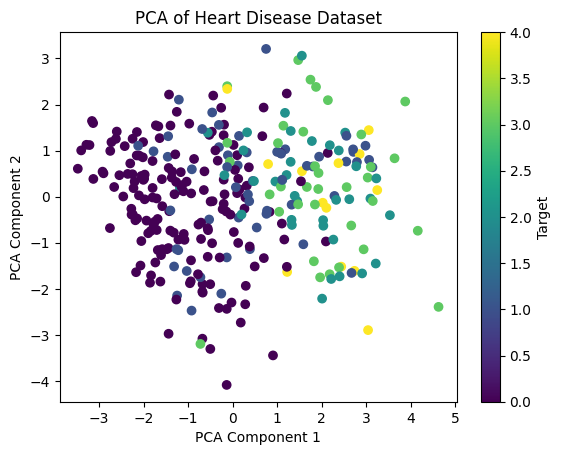

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# TODO: Use PCA to reduce to 2D for visualization
# LINES: 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA result
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['target'])
plt.title('PCA of Heart Disease Dataset')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Target')
plt.show()

### Task 01-3: Description (0 pts.)
#### Visualize Data with t-SNE

Unfortunately PCA doesn't do anything to make sure our data points maintain their **local structure** — two points that were close together in 13D might end up far apart in 2D. It's optimizing for global variance, not local neighborhoods.

A better option for visualization is [`t-SNE (t-distributed Stochastic Neighbor Embedding)`](https://scikit-learn.org/stable/modules/manifold.html#t-sne). t-SNE works by:
1. Computing the probability that pairs of points are "neighbors" in high-dimensional space
2. Finding a 2D layout where those neighborhood probabilities are preserved as well as possible

The result is that clusters and local structure in the original data tend to show up much more clearly in t-SNE plots. Below you can see a comparison of different manifold learning methods (including t-SNE) on the digits dataset — notice how t-SNE tends to produce tighter, more separated clusters:

![Comparison of manifold learning methods including t-SNE](https://scikit-learn.org/stable/_images/sphx_glr_plot_lle_digits_013.png)

**Note:** t-SNE is non-deterministic — you'll get slightly different results each time you run it! You can set `random_state=42` for reproducibility.

**Note:** t-SNE is only for visualization, not for downstream ML tasks. Unlike PCA, the axes of a t-SNE plot don't have a meaningful interpretation.

Use sklearn's [`TSNE`](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) to reduce to 2 components.

### Task 01-3: Code (0.25 pts.)

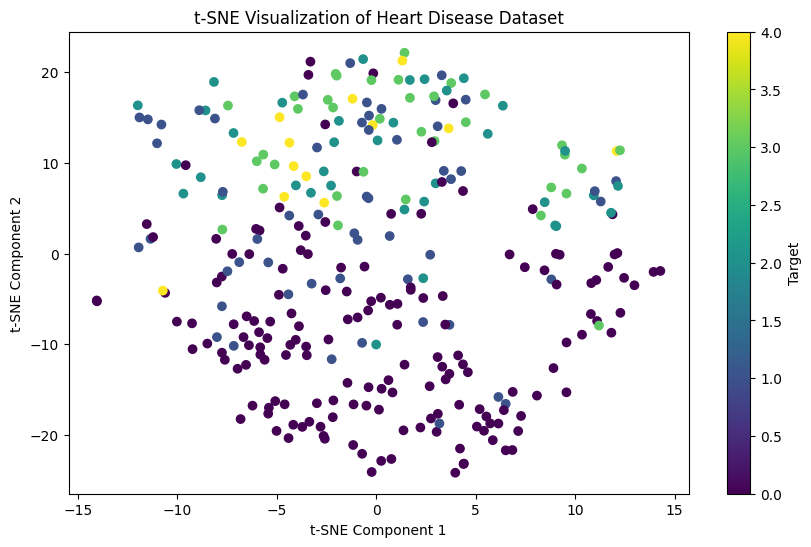

In [5]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# TODO: Apply t-SNE to the scaled dataset
# LINES: 2
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot the t-SNE result
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['target'])
plt.colorbar(label='Target')
plt.title('t-SNE Visualization of Heart Disease Dataset')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

Well things are certainly more spread out than in PCA but I don't really see any clear clusters. However we can try clustering with K-Means and see if we can find any, no need to just guess visually!

### Task 01-4: Description (0 pts.)
#### Cluster with KMeans

[`K-Means`](https://scikit-learn.org/stable/modules/clustering.html#k-means) is one of the simplest unsupervised clustering algorithms. It works by:
1. Randomly placing `K` centroids in the feature space
2. Assigning each data point to its nearest centroid
3. Moving each centroid to the mean of its assigned points
4. Repeating steps 2-3 until convergence

![K-Means convergence animation](https://upload.wikimedia.org/wikipedia/commons/e/ea/K-means_convergence.gif)

Luckily we know there should be 5 distinct groups in our data (classes 0-4), so let's see how KMeans would split our data into 5 different groups. Because we actually have the labels, we can overlay them to try and get a sense of how separable our data actually is!

Use sklearn's [`KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) with `n_clusters=5`.

### Task 01-4: Code (0.25 pts.)

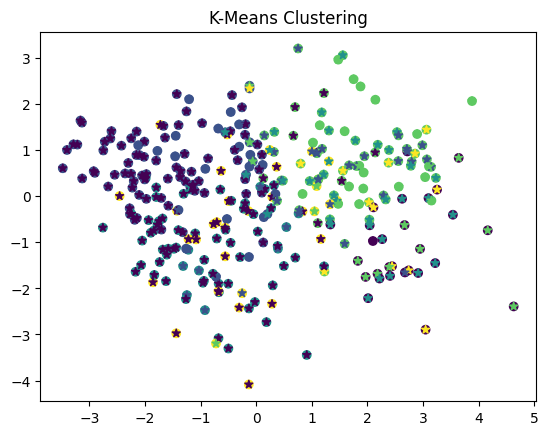

In [6]:
from sklearn.cluster import KMeans

# TODO: Apply K-Means
# LINES: 2
kmeans = KMeans(n_clusters=5, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled)

# Plot K-Means result
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['target'], marker='*')
plt.title('K-Means Clustering')
plt.show()

There's definitely some clear groupings here, but that's kind of to be expected with KMeans, since it will always force an answer — even if the data doesn't have natural clusters, KMeans will still partition it into `K` groups.

## Task 02: Evaluating Supervised Classifiers
### Task 02-1: Description (0 pts.)
#### Initialize Hyperparameter Grid

Since we have ground-truth labels, we can use supervised learning techniques to try and get that `80%` accuracy we need! Let's start with a [`Support Vector Machine (SVM)`](https://scikit-learn.org/stable/modules/svm.html#classification).

SVMs work by finding the hyperplane that best separates classes in the feature space. The "support vectors" are the data points closest to the decision boundary — they're the ones that actually determine where the boundary goes.

![SVM margin and support vectors](https://upload.wikimedia.org/wikipedia/commons/7/72/SVM_margin.png)

SVMs have several important hyperparameters:
- **`kernel`**: The function used to map data into a higher-dimensional space (`'linear'`, `'rbf'`, `'poly'`)
- **`C`**: Controls the trade-off between a smooth decision boundary and classifying training points correctly (higher C = more complex boundary)
- **`gamma`**: How much influence a single training example has (higher gamma = closer points have more influence)
- **`degree`**: Only matters for `'poly'` kernel — the degree of the polynomial

Rather than manually trying every combination, we'll use [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) to systematically test them all with cross-validation!

Define a `param_grid` dictionary with at least 2 values each for `kernel`, `C`, `degree`, and `gamma`. Then create a `GridSearchCV` object.

### Task 02-1: Code (0.5 pts.)

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define the SVM model
svm = SVC()

# TODO: Define the parameter grid to search
# LINES: 6
param_grid = {
    'kernel': ['linear', 'poly', 'rbf'],
    'C': [0.1, 1, 10],
    'degree': [2, 3, 4],
    'gamma': ['scale', 'auto']
}

# TODO: Initialize GridSearchCV with cross-validation
# LINES: 1
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, scoring='accuracy')
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['target'], test_size=0.3, random_state=42)

### Task 02-2: Description (0 pts.)
#### Test SVM with Grid Search

Now let's actually run the grid search! This will train an SVM for every combination of hyperparameters you defined above, using cross-validation to evaluate each one. Cross-validation splits the training data into `K` folds, trains on `K-1` of them, and tests on the held-out fold — then rotates which fold is held out and averages the results.

![Cross-validation diagram](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

This gives us a much more reliable estimate of how well each hyperparameter combination will generalize to unseen data.

**Note:** This may take a minute or two depending on how many combinations you defined!

### Task 02-2: Code (0.25 pts.)

In [8]:
# TODO: Fit the grid search to the training data
# LINES: 1
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'degree': [2, 3, 4],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf']},
             scoring='accuracy')

### Task 02-3: Description (0 pts.)
#### Evaluate Results of Grid Search

Let's print out the metrics for our different combinations and see what the best set is! The code below extracts the results into a nice table and prints the best parameters.

After finding the best SVM, use sklearn's [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) to show precision, recall, and F1-score for each class.

**Note:** `classification_report` is much more informative than just accuracy — it shows you how well the model does on **each class separately**, which matters a lot when classes are imbalanced!

### Task 02-3: Code (0.25 pts.)

In [9]:
# Extract results into a DataFrame
results = pd.DataFrame(grid_search.cv_results_)

# Select relevant columns and rename 'mean_test_score' to 'accuracy'
results = results[['mean_test_score', 'param_kernel', 'param_C', 'param_degree', 'param_gamma']]
results.rename(columns={'mean_test_score': 'accuracy'}, inplace=True)

# Fill NaN values for non-applicable parameters with 'None' for clarity
results.fillna('None', inplace=True)

# Reorder columns to make 'accuracy' the first column
results = results[['accuracy', 'param_kernel', 'param_C', 'param_degree', 'param_gamma']]

# Sort by accuracy
results = results.sort_values(by='accuracy', ascending=False)

# Print the table with all columns
pd.set_option('display.max_columns', None)
print(results)

# Print the best parameters and best score
print("\nBest parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))

# Use the best estimator to make predictions
best_svm = grid_search.best_estimator_
y_pred_best_svm = best_svm.predict(X_test)

# TODO: Display classification report for the best SVM model
# LINES: 1
print("\nBest SVM Model Classification Report:\n", classification_report(y_test, y_pred_best_svm))

    accuracy param_kernel  param_C  param_degree param_gamma
20  0.584828          rbf      1.0             2       scale
35  0.584828          rbf      1.0             4        auto
32  0.584828          rbf      1.0             4       scale
29  0.584828          rbf      1.0             3        auto
26  0.584828          rbf      1.0             3       scale
23  0.584828          rbf      1.0             2        auto
24  0.570764       linear      1.0             3       scale
27  0.570764       linear      1.0             3        auto
33  0.570764       linear      1.0             4        auto
18  0.570764       linear      1.0             2       scale
21  0.570764       linear      1.0             2        auto
30  0.570764       linear      1.0             4       scale
36  0.570764       linear     10.0             2       scale
42  0.570764       linear     10.0             3       scale
51  0.570764       linear     10.0             4        auto
39  0.570764       linea

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Task 02-4: Description (0 pts.)
#### Visualize Classification Results with Confusion Matrix

A [`Confusion Matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) is a table that shows, for each true class, how many samples were predicted as each class. The diagonal shows correct predictions, and everything off-diagonal is an error.

![Confusion matrix example from sklearn](https://scikit-learn.org/stable/_images/sphx_glr_plot_confusion_matrix_001.png)

This is incredibly useful for understanding **what kinds of mistakes** your model is making. For example, is it confusing class 1 with class 2? Or is it just predicting class 0 for everything?

Use sklearn's [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) to compute `cm_best_svm`.

### Task 02-4: Code (0.25 pts.)

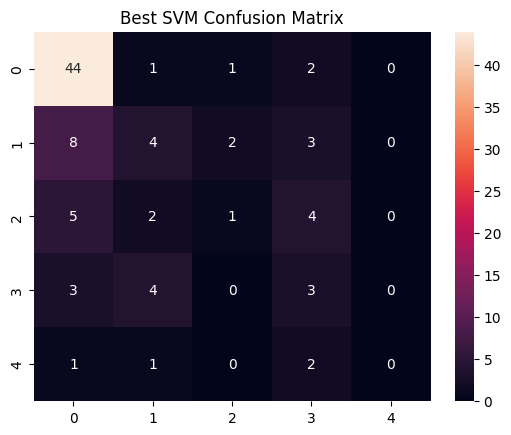

In [10]:
# TODO: Confusion matrix for the best SVM model
# LINES: 1
cm_best_svm = confusion_matrix(y_test, y_pred_best_svm)

sns.heatmap(cm_best_svm, annot=True, fmt='d')
plt.title('Best SVM Confusion Matrix')
plt.show()

### Task 02-5: Description (0 pts.)
#### Balance Dataset

The confusion matrix makes it clear that our dataset is really imbalanced — the model is probably just predicting the majority class (0) most of the time and getting "good" accuracy from that alone.

This is a classic problem in ML! Luckily, there's a technique called [`SMOTE (Synthetic Minority Over-sampling Technique)`](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) that can help. SMOTE works by:
1. For each sample in the minority class, finding its K nearest neighbors (also in the minority class)
2. Creating new **synthetic** samples along the line between the original sample and its neighbors

![SMOTE generating synthetic samples between neighbors](https://imbalanced-learn.org/stable/_images/sphx_glr_plot_illustration_generation_sample_001.png)

This gives us a balanced dataset without simply duplicating existing samples (which would cause overfitting).

**Note:** You'll need to install `imbalanced-learn` if you haven't already: `pip install imbalanced-learn`

**Note:** SMOTE should only be applied to training data, never to test data! For simplicity here we're applying it to the whole dataset before splitting — in production you'd want to be more careful.

### Task 02-5: Code (0.25 pts.)

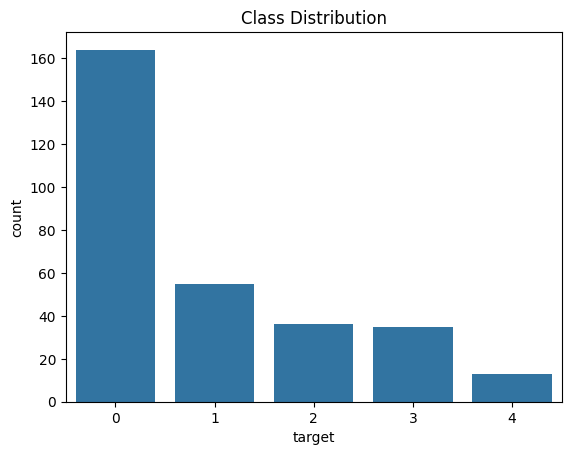

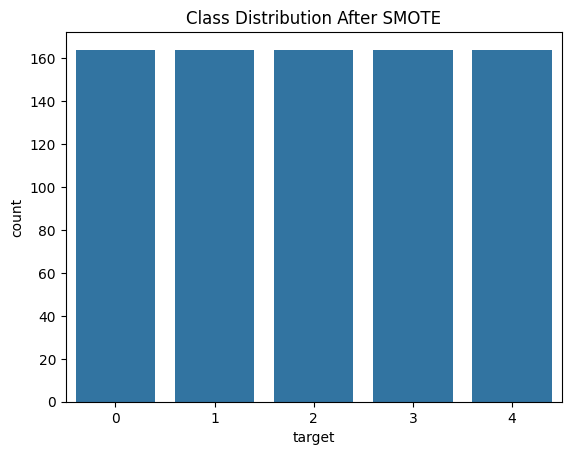

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# EDA: Check class distribution
sns.countplot(x='target', data=df)
plt.title('Class Distribution')
plt.show()

X = df.drop(columns='target')
y = df['target']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Check new class distribution
sns.countplot(x=y_resampled)
plt.title('Class Distribution After SMOTE')
plt.show()

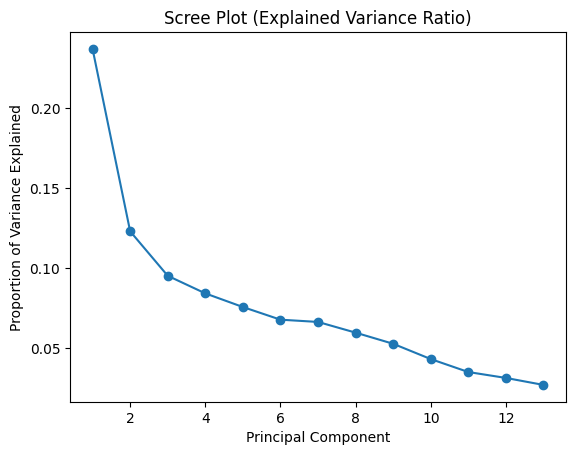

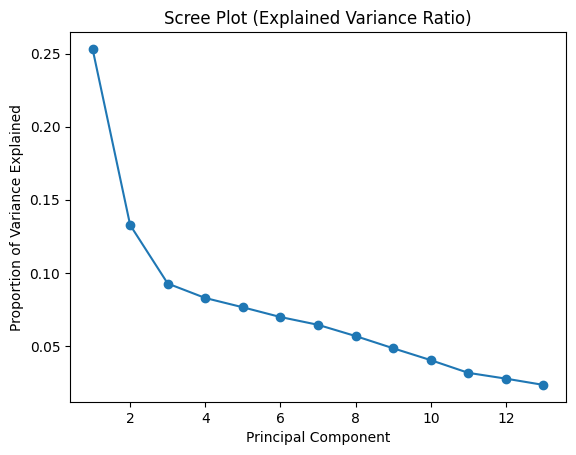

In [12]:
pca = PCA()
pca.fit(X_scaled)
explained_ratio = pca.explained_variance_ratio_

plt.plot(range(1, len(explained_ratio) + 1), explained_ratio, marker='o')
plt.title('Scree Plot (Explained Variance Ratio)')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.show()

pca = PCA()
pca.fit(X_resampled)
explained_ratio = pca.explained_variance_ratio_

plt.plot(range(1, len(explained_ratio) + 1), explained_ratio, marker='o')
plt.title('Scree Plot (Explained Variance Ratio)')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.show()

### Task 02-6: Description (0 pts.)
#### Compare Classifiers on Balanced and Unbalanced Dataset

Now that we have a balanced dataset, let's see what difference it made! We'll compare several different supervised classifiers:

| Classifier | How it works |
|---|---|
| **Logistic Regression** | Fits a linear decision boundary using the logistic function |
| **KNN** | Classifies based on the majority vote of K nearest neighbors |
| **Decision Tree** | Splits the feature space into regions using a tree of if/else rules |
| **Naive Bayes** | Uses Bayes' theorem assuming features are independent |
| **SVM (RBF)** | Finds a non-linear decision boundary using the RBF kernel |

We'll evaluate each using [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) on both the original imbalanced data and the SMOTE-balanced data to see which classifiers benefit most from balancing.

### Task 02-6: Code (0.5 pts.)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

def plot_pca_performance(X, y, pca_components_list):
    models = {
        'LogReg': LogisticRegression(max_iter=1000, random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=8),
        'Tree': DecisionTreeClassifier(max_depth=3, random_state=0),
        'NB': GaussianNB()
    }

    feature_selector = SelectKBest(score_func=f_classif, k='all')

    results = {name: [] for name in models.keys()}

    for n_components in pca_components_list:
        for name, model in models.items():
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', feature_selector),
                ('pca', PCA(n_components=n_components)),
                ('model', model)
            ])

            scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
            results[name].append(scores.mean())

    # Plot
    plt.figure()

    for name, accs in results.items():
        plt.plot(pca_components_list, accs, marker='o', label=name)

    plt.xlabel('Number of PCA Components')
    plt.ylabel('Cross-Validated Accuracy')
    plt.title('Model Performance vs PCA Dimensionality')
    plt.legend()
    plt.grid()

    plt.show()

Imbalanced:


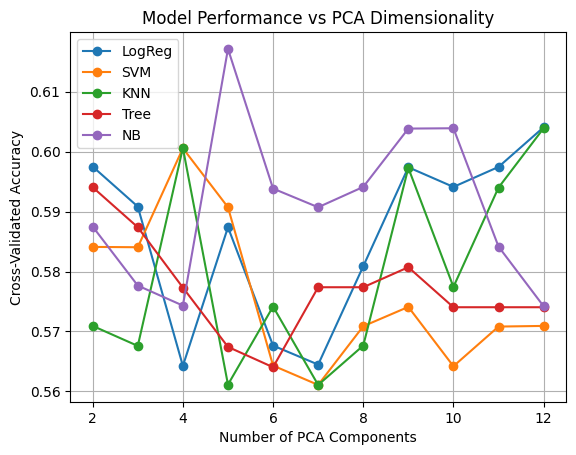

Balanced:


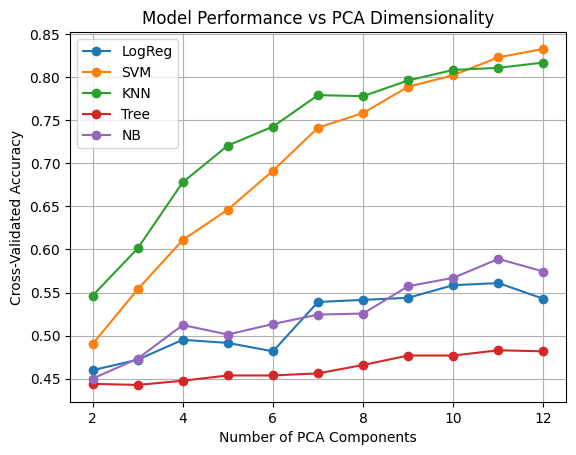

In [14]:
pca_sizes = list(range(2, min(X.shape[1], 12) + 1))

print("Imbalanced:")
plot_pca_performance(X, df['target'], pca_sizes)

print("Balanced:")
plot_pca_performance(X_resampled, y_resampled, pca_sizes)

### *Story Progression*
While balancing the classes didn't help every method equally, it greatly improved the SVM's and KNN's performance.

Unfortunately though, none of these classifiers were able to get to the 80% accuracy that the Dogtors wanted and so maybe we can't save any pets after all :(

## Task 03: Ensemble Learning
### Task 03-1: Description (0 pts.)
#### Simple Voting Ensemble Classifier

What if instead of relying on a single classifier, we combined several of them and let them **vote** on the answer? This is the idea behind [`Ensemble Learning`](https://scikit-learn.org/stable/modules/ensemble.html) — combining multiple "weak" learners to create a stronger one.

A [`VotingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html) does exactly this: it trains multiple different classifiers and then takes the majority vote (or weighted average of probabilities) to make the final prediction.

![Voting classifier decision regions](https://scikit-learn.org/stable/_images/sphx_glr_plot_voting_decision_regions_001.png)

The intuition is that different classifiers make different kinds of errors, so by combining them, the errors can cancel out! Create a voting ensemble using Logistic Regression, Random Forest, and Gradient Boosting.

### Task 03-1: Code (0.5 pts.)

In [15]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def evaluate_voting_ensemble(X, y):
    # TODO: Feature selection
    # LINES: 1
    feature_selector = SelectKBest(score_func=f_classif, k='all')

    # TODO: Dimensionality reduction
    # LINES: 1
    pca = PCA(n_components=8)

    # TODO: Ensemble method: Voting Classifier
    # LINES: 5
    ensemble = VotingClassifier(estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42))
    ], voting='soft')

    # TODO: Create a pipeline for the ensemble
    # LINES: 1
    ensemble_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('feature_selection', feature_selector),
        ('pca', pca),
        ('ensemble', ensemble)
    ])

    # TODO: Perform cross-validation for the ensemble
    # LINES: 1
    ensemble_scores = cross_val_score(ensemble_pipeline, X, y, cv=5, scoring='accuracy')
    print(f"Ensemble (Voting) Accuracy: {ensemble_scores.mean():.2f} (+/- {ensemble_scores.std() * 2:.2f})")

# Evaluate on the scaled dataset
print('Imbalanced Results:')
evaluate_voting_ensemble(X_scaled, df['target'])

print('-' * 80)

# Evaluate on the resampled dataset
print('Balanced Results:')
evaluate_voting_ensemble(X_resampled, y_resampled)

Imbalanced Results:
Ensemble (Voting) Accuracy: 0.61 (+/- 0.08)
--------------------------------------------------------------------------------
Balanced Results:
Ensemble (Voting) Accuracy: 0.83 (+/- 0.06)


### Task 03-2: Description (0 pts.)
#### Stacking Ensemble Classifier

Voting is simple but treats all classifiers equally. What if we could **learn** which classifiers to trust more?

A [`StackingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html) does this by training a "meta-learner" on top of the base classifiers. The process is:
1. Train the base classifiers (e.g., Random Forest, Gradient Boosting, Logistic Regression)
2. Use the **predictions** of those base classifiers as **features** for a final classifier (the meta-learner)
3. The meta-learner learns the optimal way to combine the base predictions

![Stacking classifier combining multiple estimators](https://scikit-learn.org/stable/_images/sphx_glr_plot_stack_predictors_001.png)

This is more powerful than voting because the meta-learner can learn things like "trust the Random Forest on class 3 but trust Logistic Regression on class 0."

Create a stacking ensemble with the same base classifiers and a `LogisticRegression` as the final estimator.

### Task 03-2: Code (0.5 pts.)

In [16]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def evaluate_stacking_ensemble(X, y):
    # TODO: Feature selection
    # LINES: 1
    feature_selector = SelectKBest(score_func=f_classif, k='all')

    # TODO: Dimensionality reduction
    # LINES: 1
    pca = PCA(n_components=8)

    # TODO: Ensemble method: Stacking Classifier
    # LINES: 6
    ensemble = StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=42)),
            ('rf', RandomForestClassifier(random_state=42)),
            ('gb', GradientBoostingClassifier(random_state=42))
        ],
        final_estimator=LogisticRegression(max_iter=1000)
    )

    # TODO: Create a pipeline for the ensemble
    # LINES: 1
    ensemble_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('feature_selection', feature_selector),
        ('pca', pca),
        ('ensemble', ensemble)
    ])

    # TODO: Perform cross-validation for the ensemble
    # LINES: 1
    ensemble_scores = cross_val_score(ensemble_pipeline, X, y, cv=5, scoring='accuracy')
    print(f"Ensemble (Stacking) Accuracy: {ensemble_scores.mean():.2f} (+/- {ensemble_scores.std() * 2:.2f})")

# Evaluate on the scaled dataset
print('Imbalanced Results:')
evaluate_stacking_ensemble(X_scaled, df['target'])

print('-' * 80)

# Evaluate on the resampled dataset
print('Balanced Results:')
evaluate_stacking_ensemble(X_resampled, y_resampled)

Imbalanced Results:
Ensemble (Stacking) Accuracy: 0.63 (+/- 0.06)
--------------------------------------------------------------------------------
Balanced Results:
Ensemble (Stacking) Accuracy: 0.87 (+/- 0.04)


### *Story Progression*
#### OH MY GOODNESS WE DID IT
Would you look at that, we were able to get above 80% accuracy by simply combining different basic ML models together!

But wait, the Dogtors said that given the current state of the market they'd really love to use AI (obviously this ML stuff isn't *real* AI) to solve this problem so they can bring in more funding. It turns out there's another technique we could use!

## Task 04: [BONUS] Simple Neural Network
### Task 04: Description (0 pts.)
#### Simple Feed-Forward Network

Let's see if we can create a basic neural network to help the Dogtors get extra funding while still saving the pets!

A [`Feed-Forward Neural Network (FFN)`](https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html) is the simplest kind of neural network. Data flows in one direction: input → hidden layers → output. Each layer performs a linear transformation followed by a non-linear activation function.

![Feed-forward neural network architecture](https://upload.wikimedia.org/wikipedia/commons/4/46/Colored_neural_network.svg)

For our network, you'll need to define:
1. **Architecture** (`__init__`): At minimum, two linear layers with a ReLU activation in between. The input size should match our features (13), and the output size should match our number of classes (5).
2. **Forward pass** (`forward`): Pass the input through your layers in order.
3. **Training parameters**: A loss function ([`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) is standard for classification), an optimizer ([`Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) is a good default), and number of epochs.

**Note:** The training loop and evaluation function are already provided — you just need to define the model, loss, and optimizer!

**Note:** Neural networks are stochastic — results will vary between runs, which is why we average over 10 runs.

### Task 04: Code (1 pt.)

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def make_loader(X, y, batch_size=32, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y.values, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_scaled, df['target'], test_size=0.3, random_state=42
)

train_loader_u = make_loader(X_train_u, y_train_u, shuffle=True)
test_loader_u  = make_loader(X_test_u, y_test_u)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42
)

train_loader_b = make_loader(X_train_b, y_train_b, shuffle=True)
test_loader_b  = make_loader(X_test_b, y_test_b)

# TODO: Define a simple neural network
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        # LINES: 3
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)


    def forward(self, x):
        # LINES: 4
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Initialize the model, loss function, and optimizer
input_size = X_train_u.shape[1]
hidden_size = 128
num_classes = len(df['target'].unique())

# TODO: Initialize model, criterion, optimizer, and epochs
# LINES: 4
model = SimpleNN(input_size, hidden_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)
epochs = 100

def train_and_evaluate(model, train_loader, test_loader, criterion, optimizer, epochs=100):
    results = []
    for run in range(10):
        # Training loop
        for epoch in range(epochs):
            model.train()
            for X_batch, y_batch in train_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Evaluate the model
            model.eval()
            with torch.no_grad():
                correct = 0
                total = 0
                for X_batch, y_batch in test_loader:
                    outputs = model(X_batch)
                    _, predicted = torch.max(outputs.data, 1)
                    total += y_batch.size(0)
                    correct += (predicted == y_batch).sum().item()

                print(f'Accuracy of the model on the test set: {100 * correct / total:.2f}%')
                results.append(100 * correct / total)

    print(f'Average accuracy over {len(results)} runs: {np.mean(results):.2f}%')

print("Unbalanced Dataset Results:")
train_and_evaluate(model, train_loader_u, test_loader_u, criterion, optimizer)

print('-' * 80)

print("Balanced Dataset Results:")
train_and_evaluate(model, train_loader_b, test_loader_b, criterion, optimizer)

Unbalanced Dataset Results:
Accuracy of the model on the test set: 56.04%
Accuracy of the model on the test set: 60.44%
Accuracy of the model on the test set: 60.44%
Accuracy of the model on the test set: 57.14%
Accuracy of the model on the test set: 57.14%
Accuracy of the model on the test set: 58.24%
Accuracy of the model on the test set: 57.14%
Accuracy of the model on the test set: 58.24%
Accuracy of the model on the test set: 59.34%
Accuracy of the model on the test set: 59.34%
Accuracy of the model on the test set: 60.44%
Accuracy of the model on the test set: 56.04%
Accuracy of the model on the test set: 57.14%
Accuracy of the model on the test set: 54.95%
Accuracy of the model on the test set: 53.85%
Accuracy of the model on the test set: 57.14%
Accuracy of the model on the test set: 52.75%
Accuracy of the model on the test set: 52.75%
Accuracy of the model on the test set: 53.85%
Accuracy of the model on the test set: 52.75%
Accuracy of the model on the test set: 52.75%
Accura

## Wrap-Up

In this practicum, we worked through the full ML pipeline on the Heart Disease dataset:

1. **Unsupervised Exploration** — Used PCA, t-SNE, and KMeans to understand the structure of our data before training any models
2. **Supervised Classification** — Trained an SVM with grid search and evaluated it with classification reports and confusion matrices
3. **Handling Imbalanced Data** — Used SMOTE to synthetically balance our classes and compared the effect across multiple classifiers
4. **Ensemble Methods** — Combined classifiers with Voting and Stacking to push past the 80% accuracy threshold
5. **[BONUS] Neural Networks** — Built a simple feed-forward network in PyTorch and compared performance on balanced vs. unbalanced data

The key takeaway: no single technique is a silver bullet. Understanding your data (class imbalance!), trying multiple approaches, and combining them intelligently is what gets results.

## Task 05: Generate Submission (0 pts.)
### Task 05: Description (0 pts.)

Run the cell below to generate your submission file.

### Task 05: Code (0 pts.)

In [18]:
import os, json

def export_notebook():
    L_PATH = "cse-30124-homeworks/Notebooks"
    L = "Practicum"

    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        src  = f"/content/{L}.ipynb"
        dest = f"/content/drive/MyDrive/{L_PATH}"
        os.makedirs(dest, exist_ok=True)
        !cp "{src}" "{dest}/{L}.ipynb"
        print(f"Saved to Google Drive: {dest}/{L}.ipynb")
    except ImportError:
        print("Not running in Colab — save your notebook manually.")

export_notebook()

ValueError: mount failed